## 

# Hybrid Model

### Cultural Dimensions and Mortality

Dataset size (num countries trained): 78
Epoch 1/2000  avg_loss=0.256098
Epoch 25/2000  avg_loss=0.032131
Epoch 50/2000  avg_loss=0.006007
Epoch 75/2000  avg_loss=0.002753
Epoch 100/2000  avg_loss=0.002876
Epoch 125/2000  avg_loss=0.002573
Epoch 150/2000  avg_loss=0.001719
Epoch 175/2000  avg_loss=0.001411
Epoch 200/2000  avg_loss=0.000703
Epoch 225/2000  avg_loss=0.000564
Epoch 250/2000  avg_loss=0.000363
Epoch 275/2000  avg_loss=0.000365
Epoch 300/2000  avg_loss=0.000236
Epoch 325/2000  avg_loss=0.001110
Epoch 350/2000  avg_loss=0.001077
Epoch 375/2000  avg_loss=0.000244
Epoch 400/2000  avg_loss=0.000191
Epoch 425/2000  avg_loss=0.000146
Epoch 450/2000  avg_loss=0.000134
Epoch 475/2000  avg_loss=0.000165
Epoch 500/2000  avg_loss=0.000147
Epoch 525/2000  avg_loss=0.000106
Epoch 550/2000  avg_loss=0.000096
Epoch 575/2000  avg_loss=0.000137
Epoch 600/2000  avg_loss=0.000120
Epoch 625/2000  avg_loss=0.000111
Epoch 650/2000  avg_loss=0.000127
Epoch 675/2000  avg_loss=0.000103
Epoch 700/20

/tmp/ipykernel_1867971/1310963460.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 14)


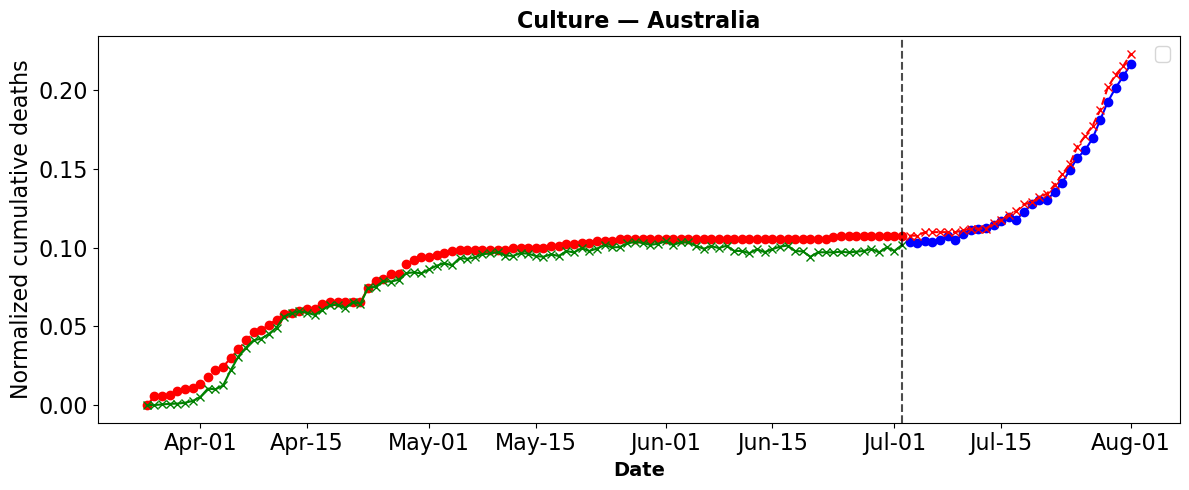

/tmp/ipykernel_1867971/1310963460.py:300: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 14)


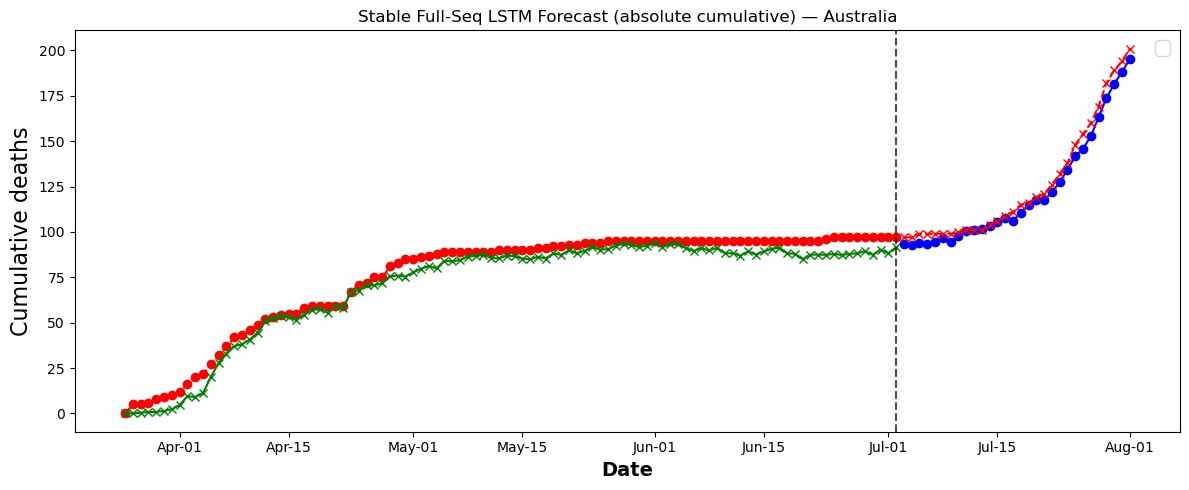

In [10]:


import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


                                                                                        

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


                                                                                           

ENC_LEN = 100
FORECAST_LEN = 30
TOTAL_LEN = ENC_LEN + FORECAST_LEN
BATCH_SIZE = 32
EPOCHS = 2000
LR = 1e-3
HIDDEN = 128
NUM_LAYERS = 2
FORECAST_WEIGHT = 1.0                                                                  

                                                                                       

path = "Merged_1.csv"
df = pd.read_csv(path)

df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)


                                                            

df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
df['daily_deaths'] = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = df.groupby('Country')['daily_deaths'].cumsum()

                                                                               
country_max = df.groupby('Country')['CumulativeDeaths'].transform('max').replace(0, 1.0)
df['cumulative_norm'] = df['CumulativeDeaths'] / country_max
df['daily_norm'] = df['daily_deaths'] / country_max


                                                                                    
fixed_features = [
    'Individualism','Masculinity','Power Distance','Indulgence',
    'Uncertainty Avoidance','Long Term Orientation'
]

for c in fixed_features:
    if c not in df.columns:
        df[c] = 0.0
# simple z-score over all countries 
df[fixed_features] = (df[fixed_features].fillna(0) - df[fixed_features].fillna(0).mean()) / (df[fixed_features].fillna(0).std() + 1e-9)



dynamic_cols = ['daily_norm', 'cumulative_norm']   
static_cols = fixed_features                       

class CountryFullSeqDataset(Dataset):
    def __init__(self, df, dynamic_cols, static_cols, enc_len=ENC_LEN, forecast_len=FORECAST_LEN):
        self.enc_len = enc_len
        self.forecast_len = forecast_len
        self.total_len = enc_len + forecast_len
        self.dynamic_cols = dynamic_cols
        self.static_cols = static_cols
        self.samples = []

        for country, g in df.groupby('Country'):
            g = g.sort_values('Date').reset_index(drop=True)
            if len(g) >= self.total_len:
                dyn = g[self.dynamic_cols].values.astype(np.float32)  
                stat = g[self.static_cols].iloc[0].values.astype(np.float32)  
                target = g['cumulative_norm'].values.astype(np.float32)  
                dates = g['Date'].values.copy()
                total_deaths = g['CumulativeDeaths'].values.copy()  
                # store
                self.samples.append({
                    'country': country,
                    'dyn': dyn,
                    'stat': stat,
                    'target': target,
                    'dates': dates,
                    'abs_cum': total_deaths
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        x_dyn = s['dyn'][:self.enc_len]                                                                         
        x_stat = s['stat']                                                                                      
        y_full = s['target'][:self.total_len]                                                                   
        return torch.tensor(x_dyn), torch.tensor(x_stat), torch.tensor(y_full), s['country']




class FullSeqLSTM(nn.Module):
    def __init__(self, dyn_dim, static_dim, hidden_dim=HIDDEN, num_layers=NUM_LAYERS, total_len=TOTAL_LEN):
        super().__init__()
        self.dyn_dim = dyn_dim
        self.static_dim = static_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.total_len = total_len

        # LSTM encoder
        self.lstm = nn.LSTM(input_size=dyn_dim + static_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, bidirectional=False)

        # static encoder MLP
        self.static_mlp = nn.Sequential(
            nn.Linear(static_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.total_len),
        )

        
        self.out_act = nn.Sigmoid()

    def forward(self, x_dyn, x_stat):
        
        B, T, D = x_dyn.shape
        # repeat static across time and concat
        stat_rep = x_stat.unsqueeze(1).repeat(1, T, 1)                                               
        lstm_in = torch.cat([x_dyn, stat_rep], dim=-1)                                               
        out, (h_n, c_n) = self.lstm(lstm_in)                                                         
        h_last = h_n[-1]                                                                             
        stat_enc = self.static_mlp(x_stat)                                                           
        comb = torch.cat([h_last, stat_enc], dim=-1)                                                 
        dec = self.decoder(comb)                                                                     
        return self.out_act(dec)                                                                     


# Training utilities

def train_model(model, loader, epochs=EPOCHS, lr=LR, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(device)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for x_dyn, x_stat, y_full, _ in loader:
            x_dyn = x_dyn.to(device)                                                             
            x_stat = x_stat.to(device)                                                         
            y_full = y_full.to(device)                                                        

            pred_full = model(x_dyn, x_stat)                                                  
            # split train / forecast
            pred_train = pred_full[:, :ENC_LEN]
            pred_fore = pred_full[:, ENC_LEN:]
            y_train = y_full[:, :ENC_LEN]
            y_fore = y_full[:, ENC_LEN:]

            loss_train = loss_fn(pred_train, y_train)
            loss_fore = loss_fn(pred_fore, y_fore)
            loss = loss_train + FORECAST_WEIGHT * loss_fore

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            total_loss += loss.item()
        if ep % 25 == 0 or ep == 1:                                       


          print(f"Epoch {ep}/{epochs}  avg_loss={total_loss/len(loader):.6f}")
    return model


                                                                                        

dataset = CountryFullSeqDataset(df, dynamic_cols=dynamic_cols, static_cols=static_cols,
                                enc_len=ENC_LEN, forecast_len=FORECAST_LEN)
if len(dataset) == 0:
    raise RuntimeError("No countries have enough length for ENC_LEN+FORECAST_LEN. Reduce ENC_LEN or FORECAST_LEN or check data.")
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

model = FullSeqLSTM(dyn_dim=len(dynamic_cols), static_dim=len(static_cols),
                    hidden_dim=HIDDEN, num_layers=NUM_LAYERS, total_len=TOTAL_LEN)

print("Dataset size (num countries trained):", len(dataset))
model = train_model(model, loader, epochs=EPOCHS, lr=LR)


                                                                                        

country_name = "Australia"                                                               
g = df[df['Country'] == country_name].sort_values('Date').reset_index(drop=True)

if len(g) < TOTAL_LEN:
    raise RuntimeError(f"{country_name} does not have >= {TOTAL_LEN} days; has {len(g)}")

                                                                                      
dyn_enc = torch.tensor(g[dynamic_cols].values[:ENC_LEN].astype(np.float32)).unsqueeze(0)  
stat_vec = torch.tensor(g[static_cols].iloc[0].values.astype(np.float32)).unsqueeze(0)   

model.eval()
with torch.no_grad():
    pred_full = model(dyn_enc, stat_vec).squeeze(0).cpu().numpy()  

# split pred
pred_train_cum_norm = pred_full[:ENC_LEN]
pred_fore_cum_norm = pred_full[ENC_LEN:TOTAL_LEN]

# true sequences 
true_cum_norm = g['cumulative_norm'].values[:TOTAL_LEN]
true_train_cum_norm = true_cum_norm[:ENC_LEN]
true_fore_cum_norm = true_cum_norm[ENC_LEN:TOTAL_LEN]

# convert normalized cumulative -> absolute cumulative: multiply by country_max 
country_scale_val = (g['CumulativeDeaths'].max() if g['CumulativeDeaths'].max() > 0 else 1.0)
true_train_abs = true_train_cum_norm * country_scale_val
true_fore_abs = true_fore_cum_norm * country_scale_val
pred_train_abs = pred_train_cum_norm * country_scale_val
pred_fore_abs = pred_fore_cum_norm * country_scale_val

# prepare plotting dates
dates = pd.to_datetime(g['Date'].iloc[:TOTAL_LEN])

# Plot: normalized cumulative 
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_cum_norm, 'o--', color='red')  
plt.plot(dates[:ENC_LEN], pred_train_cum_norm, 'x-', color='green')  
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_cum_norm, 'o-', color='blue') 
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_cum_norm, 'x--', color='red')  
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Culture — {country_name}",fontsize=16,fontweight='bold') 
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize=16)
plt.legend(fontsize = 14)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also plot absolute cumulative (optional)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_abs, 'o--', color='red')  
plt.plot(dates[:ENC_LEN], pred_train_abs, 'x-', color='green')  
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_abs, 'o-', color='blue') 
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_abs, 'x--', color='red') 
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Stable Full-Seq LSTM Forecast (absolute cumulative) — {country_name}")
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Cumulative deaths",fontsize=16)
plt.legend(fontsize = 14)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

#df_pred.head(20)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1867971/84568830.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


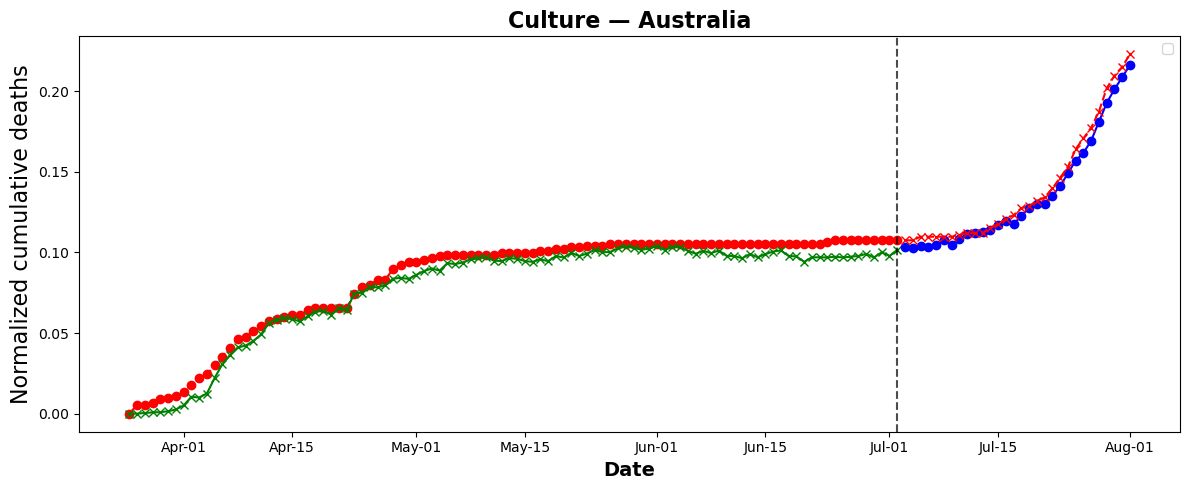

/tmp/ipykernel_1867971/84568830.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


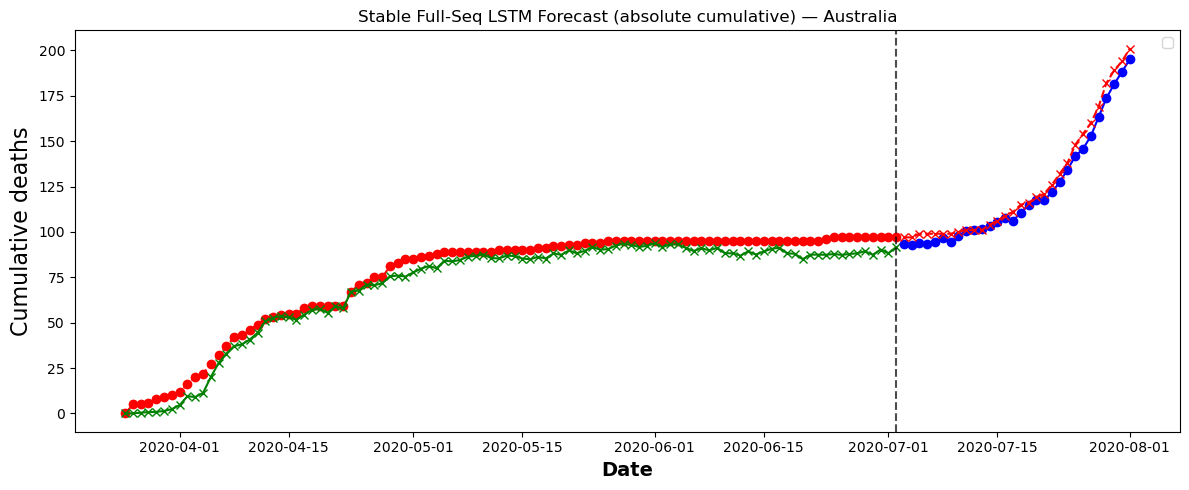

In [11]:
# Plot: normalized cumulative 
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_cum_norm, 'o--', color='red')  
plt.plot(dates[:ENC_LEN], pred_train_cum_norm, 'x-', color='green')  
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_cum_norm, 'o-', color='blue') 
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_cum_norm, 'x--', color='red')  
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Culture — {country_name}",fontsize=16,fontweight ='bold') 
plt.xlabel("Date", fontsize=14 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize=16)
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also plot absolute cumulative (optional)
plt.figure(figsize=(12,5))
plt.plot(dates[:ENC_LEN], true_train_abs, 'o--', color='red')  
plt.plot(dates[:ENC_LEN], pred_train_abs, 'x-', color='green')  
plt.plot(dates[ENC_LEN:TOTAL_LEN], pred_fore_abs, 'o-', color='blue') 
plt.plot(dates[ENC_LEN:TOTAL_LEN], true_fore_abs, 'x--', color='red') 
plt.axvline(dates[ENC_LEN-1], color='k', linestyle='--', alpha=0.7)
plt.title(f"Stable Full-Seq LSTM Forecast (absolute cumulative) — {country_name}")
plt.xlabel("Date", fontsize=14 ,fontweight ='bold')
plt.ylabel("Cumulative deaths",fontsize=16)
plt.legend()
plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
#ax.tick_params(axis='x', labelsize=16) 
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [75]:
# -------------------------
# Save predictions to CSV
# -------------------------
out_df = pd.DataFrame({
    "Date": dates,
    "True_Cumulative_Normalized": np.concatenate([true_train_cum_norm, true_fore_cum_norm]),
    "Pred_Cumulative_Normalized": np.concatenate([pred_train_cum_norm, pred_fore_cum_norm]),
    "True_Cumulative_Absolute": np.concatenate([true_train_abs, true_fore_abs]),
    "Pred_Cumulative_Absolute": np.concatenate([pred_train_abs, pred_fore_abs]),
    "Split": ["Train"] * ENC_LEN + ["Forecast"] * FORECAST_LEN
})

out_path = f"predictions_cul_{country_name}.csv"
out_df.to_csv(out_path, index=False)

print(f"Saved predictions to: {out_path}")





Saved predictions to: predictions_cul_Nigeria.csv


In [4]:
true_fore_cum_norm = true_cum_norm[ENC_LEN:TOTAL_LEN]

In [12]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Forecast metrics
forecast_mse = mean_squared_error(true_fore_cum_norm, pred_fore_cum_norm)
forecast_rmse = np.sqrt(forecast_mse)
forecast_mae = mean_absolute_error(true_fore_cum_norm, pred_fore_cum_norm)

print(f"{country_name} — Forecast MSE : {forecast_mse:.6f}")
print(f"{country_name} — Forecast RMSE: {forecast_rmse:.6f}")
print(f"{country_name} — Forecast MAE : {forecast_mae:.6f}")

Australia — Forecast MSE : 0.000026
Australia — Forecast RMSE: 0.005133
Australia — Forecast MAE : 0.004396
